In [30]:
import numpy as np
import numpy.testing as npt

from scipy import stats
from scipy.stats import t,ttest_ind
from scipy.stats import f
from scipy.stats import f_oneway
from scipy.stats import pearsonr

import statsmodels.api as sm
from statsmodels.regression._prediction import get_prediction
from statsmodels.stats.outliers_influence import OLSInfluence,MLEInfluence
from statsmodels.graphics.gofplots import qqplot_2samples,ProbPlot,qqplot
import pandas as pd
from patsy import dmatrices
from numpy.testing import assert_almost_equal, assert_allclose
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import os

# some_file.py
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,getRegressionEqn,\
                                  dispReghressionAnalysis,norm_scalling,getCorrelation,\
                                  get_variance_inflation_factors,getEigvals

In [31]:
path = os.path.join(os.getcwd(), 'DataSet', 'AcetyleneData_10_1.txt')
df = pd.read_csv(path)

See numpy API for correlations/covariance

Return Pearson product-moment correlation coefficients:

    numpy.corrcoef(x, y=None, rowvar=True, bias=<no value>, 

    ddof=<no value>, *, dtype=None)

Cross-correlation of two 1-dimensional sequences

    numpy.correlate(a, v, mode='valid')
    
Estimate a covariance matrix, given data and weights.

numpy.cov(m, y=None, rowvar=True, bias=False, ddof=None, fweights=None, aweights=None, *, dtype=None)


In [32]:
df.columns = ['P','T','H','C']
#print(df.columns)
# Convert temprature
df['T'] = norm_scalling(df['T'].to_numpy())

df['H'] = norm_scalling(df['H'].to_numpy())

df['C'] = norm_scalling(df['C'].to_numpy())

# Create models
df['TH'] = df['T']*df['H']
df['TC'] = df['T']*df['C']
df['HC'] = df['H']*df['C']
df['TSqr'] = df['T']**2
df['HSqr'] = df['H']**2
df['CSqr'] = df['C']**2

In [33]:
# Model Formulas
formulas = 'P ~ T + H + C + TH + TC + HC + TSqr + HSqr + CSqr'
print(df.head())

y, X = dmatrices(
                 formula_like = formulas, 
                 data=df,
                 return_type='dataframe'
                 )
res = sm.OLS(y, X).fit()
dispReghressionAnalysis(res)
getRegressionEqn(res)

      P         T         H         C        TH        TC        HC      TSqr  \
0  49.0  1.085304 -0.873140 -0.894874 -0.947623 -0.971211  0.781351  1.177885   
1  50.2  1.085304 -0.608218 -0.894874 -0.660101 -0.971211  0.544279  1.177885   
2  50.5  1.085304 -0.254988 -0.910678 -0.276739 -0.988362  0.232212  1.177885   
3  48.5  1.085304  0.186550 -0.863267  0.202463 -0.936907 -0.161042  1.177885   
4  47.5  1.085304  0.804702 -0.847464  0.873346 -0.919756 -0.681956  1.177885   

       HSqr      CSqr  
0  0.762374  0.800800  
1  0.369929  0.800800  
2  0.065019  0.829334  
3  0.034801  0.745231  
4  0.647545  0.718195  
=============================== Regression Analysis ========================================
             RegCoff    SE Coff          T             P
Intercept  35.895791   1.091582  32.884181  5.261059e-08
T           4.003778   4.508698   0.888012  4.087189e-01
H           2.778313   0.307076   9.047650  1.021830e-04
C          -8.042331   6.070660  -1.324787  2.33

'35.896  + 4.004 T + 2.778 H -8.042 C -6.457 TH -26.98 TC -3.768 HC -12.524 TSqr -0.973 HSqr -11.593 CSqr '

In [34]:
dfX = df.loc[:,['T', 'H', 'C', 'TH', 'TC', 'HC', 'TSqr', 'HSqr', 'CSqr']]

# Method 1: Not recommends yet
X = dfX.to_numpy()
xMat = np.mat(X)
xTrans = xMat.T
print(type(xMat),xMat.shape)
print(type(xTrans),xTrans.shape)
coorMat = np.matmul(xTrans,xMat)
print(type(coorMat),coorMat.shape)
corr = coorMat/15

<class 'numpy.matrix'> (16, 9)
<class 'numpy.matrix'> (9, 16)
<class 'numpy.matrix'> (9, 9)


In [35]:
# print(corr)

#Method 2: Pandas method
corr = dfX.corr(method='pearson')
tableDispFormatt('Correlations Matrix')
print(corr)


=============================== Correlations Matrix ========================================
             T         H         C        TH        TC        HC      TSqr  \
T     1.000000  0.223628 -0.958204 -0.132417  0.442824  0.205539 -0.270746   
H     0.223628  1.000000 -0.240231  0.038688  0.192263 -0.023066 -0.147711   
C    -0.958204 -0.240231  1.000000  0.194985 -0.660527 -0.274119  0.500962   
TH   -0.132417  0.038688  0.194985  1.000000 -0.264850 -0.974481  0.246312   
TC    0.442824  0.192263 -0.660527 -0.264850  1.000000  0.323516 -0.972244   
HC    0.205539 -0.023066 -0.274119 -0.974481  0.323516  1.000000 -0.279272   
TSqr -0.270746 -0.147711  0.500962  0.246312 -0.972244 -0.279272  1.000000   
HSqr  0.030960  0.497546 -0.017511  0.397898  0.125831 -0.374605 -0.123591   
CSqr -0.576787 -0.223906  0.765153  0.274768 -0.972167 -0.358529  0.893664   

          HSqr      CSqr  
T     0.030960 -0.576787  
H     0.497546 -0.223906  
C    -0.017511  0.765153  
TH    0.397898  0.

=============================== Correlation between groups =================================
         between      Corr          pVal
0         [T, H]  0.223628  4.050863e-01
1         [T, C] -0.958204  5.348391e-09
2        [T, TH] -0.132417  6.249365e-01
3        [T, TC]  0.442824  8.584271e-02
4        [T, HC]  0.205539  4.450623e-01
5      [T, TSqr] -0.270746  3.104683e-01
6      [T, HSqr]  0.030960  9.093803e-01
7      [T, CSqr] -0.576787  1.933311e-02
8         [H, C] -0.240231  3.701448e-01
9        [H, TH]  0.038688  8.868829e-01
10       [H, TC]  0.192263  4.756196e-01
11       [H, HC] -0.023066  9.324294e-01
12     [H, TSqr] -0.147711  5.851174e-01
13     [H, HSqr]  0.497546  4.987357e-02
14     [H, CSqr] -0.223906  4.044871e-01
15       [C, TH]  0.194985  4.692711e-01
16       [C, TC] -0.660527  5.349250e-03
17       [C, HC] -0.274119  3.042402e-01
18     [C, TSqr]  0.500962  4.807998e-02
19     [C, HSqr] -0.017511  9.486797e-01
20     [C, CSqr]  0.765153  5.529866e-04
21   

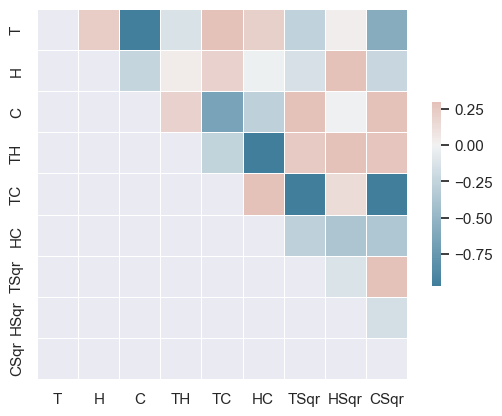

In [36]:
# Prepare Heat Map
mask = np.tril(np.ones_like(corr, dtype=int))
'''
style must be one of white, dark, whitegrid, darkgrid, ticks
'''
sns.set_theme(style="dark")
# sns.set_theme(style="whitegrid")
# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

ret = getCorrelation(data_frame = dfX,CorrelationsThreshold = 0.9)
if ret.empty == False:
    # plt.show()
    pass

# Step 2: Calculate VIFS:
tableDispFormatt('Get VIF')
ret = get_variance_inflation_factors(dfX)
print(ret)